在这个模块里面,中国目前存在不同的股票板块  
A股  
- 上交所主板：大盘蓝筹、成熟期企业为主，国企/央企集中  
- 深交所主板：2021年深市原"中小板"并入主板后，现在深交所只剩主板,以民企和创新型企业为主  
- 科创板（上交所）：硬科技属性企业，2019年设立，注册制试点  
- 创业板（深交所）：成长型创新创业企业，2009年设立  
- 北交所：脱胎于新三板，服务更早期、更小的创新型中小企业    
  
港股  
&nbsp; &nbsp; &nbsp; &nbsp; 主板、创业板（GEM）

由于中国的主流指数编撰存在相互嵌套的现象,所以我们应该找出于金价最相关的指数.  
但是存在的问题是,2019年以后,中国设立了科创板,作为上证指数的子集,而指数调换以后进一步加强了科技创新的权重,可能对指数的预测有 **新的变化**.  
并且观察主要的黄金股份,它们在上海和深圳交易所都有上市,因此以单独的市场指数来表示都不准确

在Kaggle的一个预测金价的项目中,项目提供的数据集是以标普500代表美国的宽基指数,虽然中国的沪深300与标普500组成不太一样,但是以沪深300为基础的指数,其覆盖面大概占股市的60%,而标普占据了80%,代表性沪深300更弱.  
我也会采取A500,这个指数更加接近标普500,将各方的龙头编入进来力求各行业均衡.  
此外,我自己也会编制一个新的指数,叫做黄金概念,详情见[黄金概念指数编制](../../doc/黄金概念指数编撰规则.md)

In [1]:
import yfinance as yf
import pandas as pd
from pandas import DataFrame as df

In [2]:
CSI_300_index = yf.download('000300.SS',start='2008-05-01',end='2026-7-23')
CSI_300_index.to_csv('../../data/CSI_300.csv')

[*********************100%***********************]  1 of 1 completed


In [3]:
CSI_300_index = pd.read_csv('../../data/CSI_300.csv',skiprows=[0,2])
CSI_300_index.head()

,Ticker,000300.SS,000300.SS.1,000300.SS.2,000300.SS.3,000300.SS.4
0,2021-03-11,5128.220215,5138.410156,5020.580078,5024.560059,189600
1,2021-03-12,5146.379883,5153.669922,5086.819824,5153.669922,201000
2,2021-03-15,5035.540039,5120.879883,4992.399902,5116.120117,204200
3,2021-03-16,5079.359863,5084.310059,5009.950195,5054.410156,161400
4,2021-03-17,5100.859863,5123.549805,5020.129883,5062.770020,149200


这里遇到了个问题,查看了下YahooFinance,最早的数据就是21年的.必须换一个数据库,采用akshare提取数据

In [4]:
#pip install akshare

In [5]:
import akshare as ak
CSI_300_index=ak.stock_zh_index_daily(symbol='sh000300')
# ak.stock_
#CSI_300_index.to_csv('../../data/CSI_300_actual')
CSI_300_index.head()


,date,open,high,low,close,volume
0,2002-01-04,1316.455,1316.455,1316.455,1316.455,0
1,2002-01-07,1302.084,1302.084,1302.084,1302.084,0
2,2002-01-08,1292.714,1292.714,1292.714,1292.714,0
3,2002-01-09,1272.645,1272.645,1272.645,1272.645,0
4,2002-01-10,1281.261,1281.261,1281.261,1281.261,0


只选取2008年5月1号以后的数据

In [6]:
CSI_300_index.dtypes

date       object
open      float64
high      float64
low       float64
close     float64
volume      int64
dtype: object

In [7]:
CSI_300_index['date'] = pd.to_datetime(CSI_300_index['date'])
CSI_300_index=CSI_300_index[CSI_300_index['date']>='2008-05-01']
CSI_300_index = CSI_300_index.set_index('date')
CSI_300_index.to_csv('../../data/CSI_300.csv')
CSI_300_index.head()

,open,high,low,close,volume
date,,,,,
2008-05-05,4015.212,4061.472,3972.561,4055.779,6253407300
2008-05-06,4021.073,4075.575,3961.344,4010.888,5845928000
2008-05-07,3986.129,4042.407,3821.107,3821.319,5445770600
2008-05-08,3774.044,3926.004,3761.280,3925.041,4405566800
2008-05-09,3960.886,3973.058,3806.519,3878.924,5365592900


因为中美的法定假期不一样,开始时间不一样,之后要对多个不同的数据取交集  
>如果中国股市在春节等长假中休市,把时间拉长是否会有较大的影响?  
>应该只会在画图时候缺失,在作为训练数据时由于取交集会被忽视掉.

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='date', ylabel='close'>

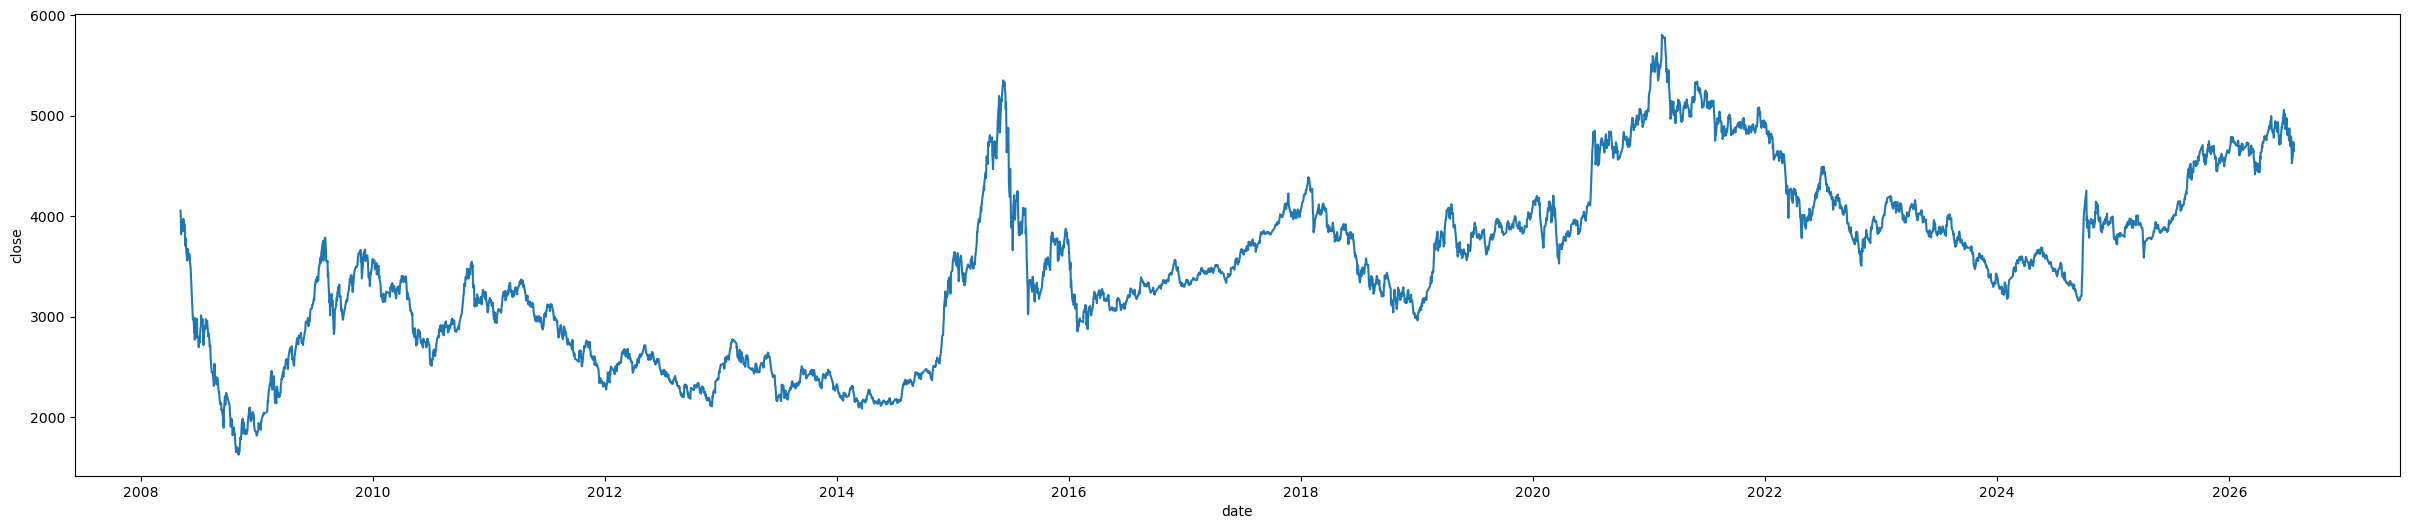

In [9]:
plt.figure(figsize=(30,6))
sns.lineplot(CSI_300_index,x='date',y='close')

In [10]:
CSI_300_index.to_csv('../../data/CSI_300_actual_alter')

In [11]:
A500_index=ak.stock_zh_index_daily(symbol='sh000510')
A500_index.head()

,date,open,high,low,close,volume
0,2005-01-04,995.421,995.421,982.745,984.640,785673530
1,2005-01-05,983.552,999.173,983.477,996.035,858145250
2,2005-01-06,996.750,996.750,984.334,987.063,723711059
3,2005-01-07,986.328,999.624,984.026,988.331,831145398
4,2005-01-10,987.780,997.697,984.353,997.697,698390802


In [12]:
A500_index['date']=pd.to_datetime(A500_index['date'])
A500_index = A500_index[A500_index['date']>='2008-5-1']
A500_index = A500_index.set_index('date')
A500_index.head()

,open,high,low,close,volume
date,,,,,
2008-05-05,3931.689,3976.044,3904.271,3972.868,7581219851
2008-05-06,3938.700,3984.624,3883.115,3933.668,7224664870
2008-05-07,3909.694,3959.834,3749.700,3749.700,6743682467
2008-05-08,3703.252,3850.233,3703.252,3850.233,5564718075
2008-05-09,3883.296,3883.621,3754.082,3811.461,6695654395


In [13]:
A500_index.to_csv('../../data/A_500.csv')

<Axes: xlabel='date', ylabel='close'>

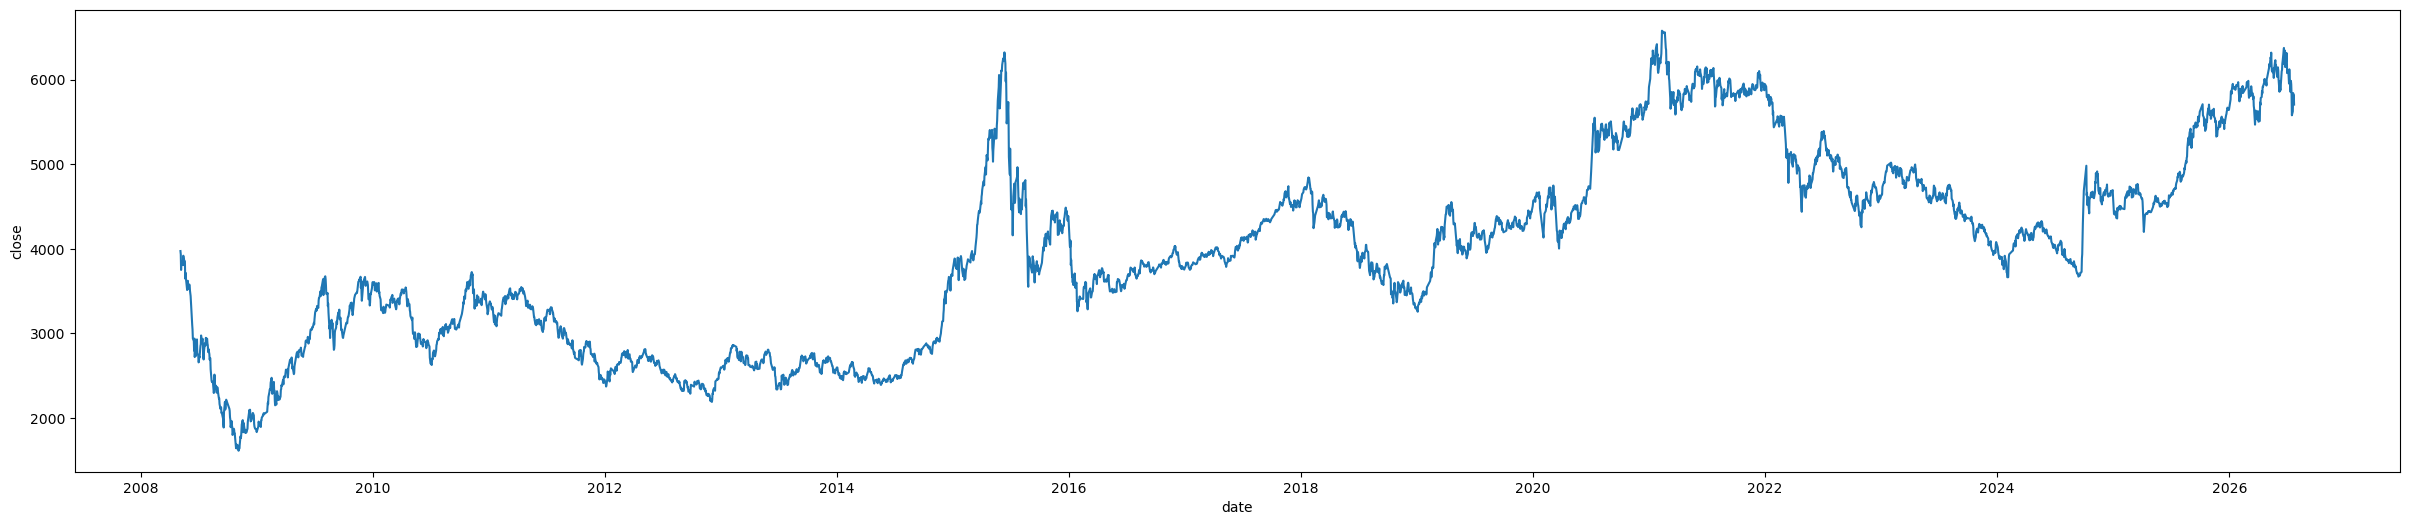

In [14]:
plt.figure(figsize=(30,6))
sns.lineplot(A500_index,x='date',y='close')

In [15]:
#此为有色金属
metal_index=ak.fund_etf_hist_sina(symbol='sh000819')
metal_index.head()
# metal_index.to_csv('../../data/metal_index.csv')

,date,prevclose,open,high,low,close,volume,amount
0,2012-05-09,5768.798,5683.090,5723.061,5605.902,5607.605,740022700,18089451520
1,2012-05-10,NaN,5582.521,5702.406,5580.490,5672.149,630264000,15322286080
2,2012-05-11,NaN,5662.713,5714.175,5597.076,5598.492,610345300,13937305600
3,2012-05-14,NaN,5643.467,5655.063,5482.461,5486.062,561489500,12728383488
4,2012-05-15,NaN,5413.958,5462.289,5348.687,5460.971,550420900,11533073408


In [16]:
metal_index = metal_index.set_index('date')
metal_index.head()

,prevclose,open,high,low,close,volume,amount
date,,,,,,,
2012-05-09,5768.798,5683.090,5723.061,5605.902,5607.605,740022700,18089451520
2012-05-10,NaN,5582.521,5702.406,5580.490,5672.149,630264000,15322286080
2012-05-11,NaN,5662.713,5714.175,5597.076,5598.492,610345300,13937305600
2012-05-14,NaN,5643.467,5655.063,5482.461,5486.062,561489500,12728383488
2012-05-15,NaN,5413.958,5462.289,5348.687,5460.971,550420900,11533073408


In [17]:
import pandas as pd

In [18]:
# metal_index = metal_index.drop(columns=['prevclose'])
metal_index.index = pd.to_datetime(metal_index.index)
metal_index = metal_index[metal_index.index>='2008-05-01']
metal_index.head()

,prevclose,open,high,low,close,volume,amount
date,,,,,,,
2012-05-09,5768.798,5683.090,5723.061,5605.902,5607.605,740022700,18089451520
2012-05-10,NaN,5582.521,5702.406,5580.490,5672.149,630264000,15322286080
2012-05-11,NaN,5662.713,5714.175,5597.076,5598.492,610345300,13937305600
2012-05-14,NaN,5643.467,5655.063,5482.461,5486.062,561489500,12728383488
2012-05-15,NaN,5413.958,5462.289,5348.687,5460.971,550420900,11533073408


In [21]:
metal_index.to_csv('../../data/metal_index.csv')

SyntaxError: unterminated string literal (detected at line 1) (302915437.py, line 1)

有色金属的概念在2012年才出现,进行比对时将时间推到2012年以后

<Axes: xlabel='date', ylabel='close'>

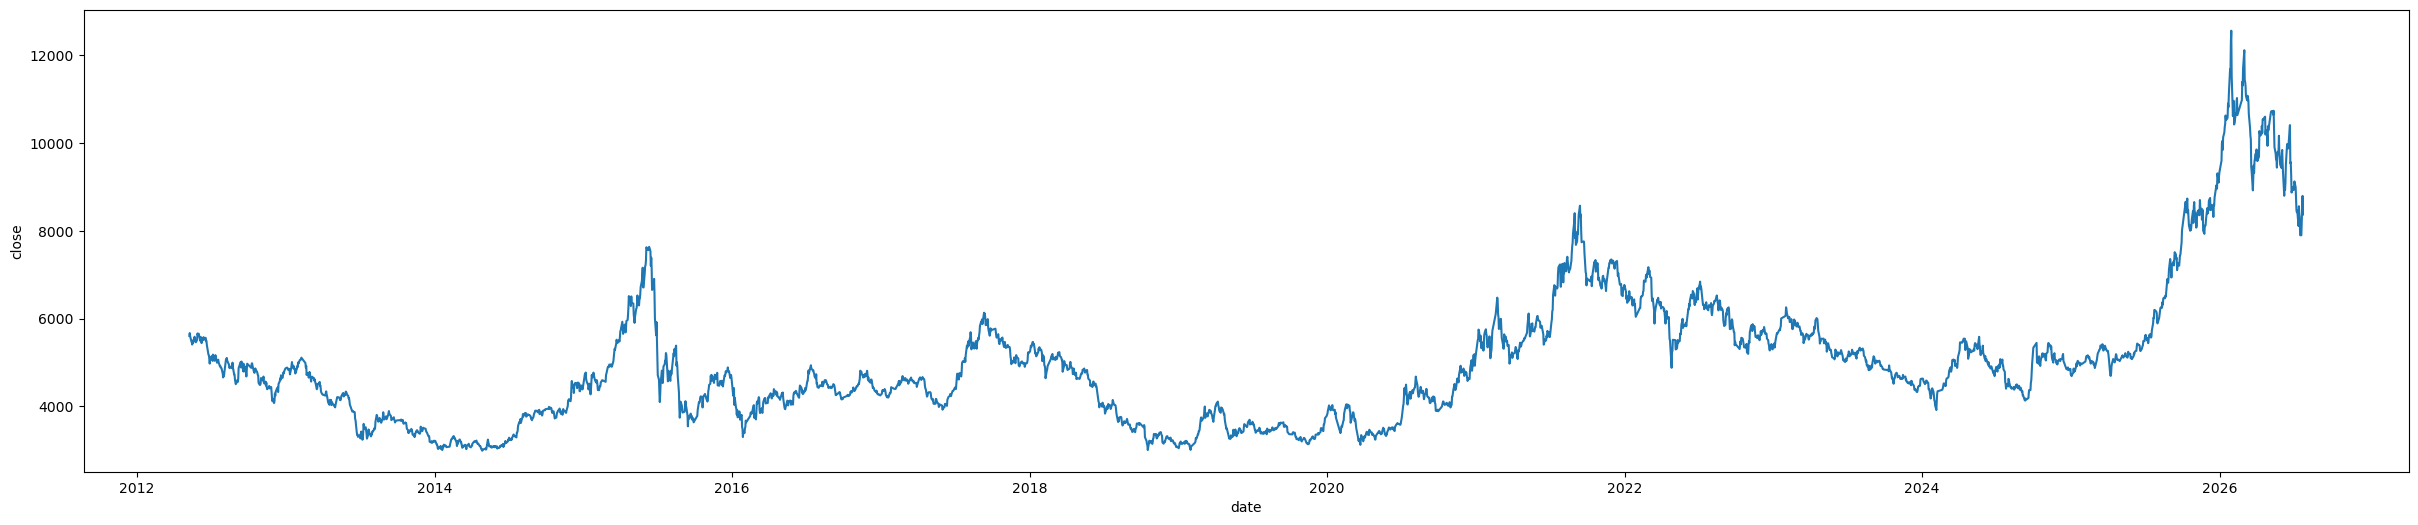

In [20]:
plt.figure(figsize=(30,6))
sns.lineplot(data=metal_index,y='close',x=metal_index.index)

下面要根据 [黄金概念指数编撰规则](../../doc/黄金概念指数编撰规则.md) 来编辑自己的黄金股票指数 , 采用两种方法  
1. 等式值加权  
2. 根据扣非净利润加权

In [ ]:
gold_company = {
    "紫金矿业": "601899",
    "山东黄金": "600547",
    "中金黄金": "600489",
    "赤峰黄金": "600988",
    "山金国际": "000975",
    "湖南黄金": "002155",
    "西部黄金": "601069",
    "恒邦股份": "002237",
    "四川黄金": "001337",
    "招金黄金": "000506",
}